In [99]:
#pip install catboost
#pip install xgboost

In [100]:
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

In [101]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
import random as rd
import optuna

import xgboost as xgb
import torch

import torch.nn as nn
from catboost import CatBoostRegressor
from xgboost import XGBRegressor

In [102]:
RAND_SEED = 1917
torch.manual_seed(seed = RAND_SEED)
np.random.seed(RAND_SEED)

In [103]:
home_dir = ""

train_df = pd.read_csv(home_dir + "train.csv")
test_df = pd.read_csv(home_dir + "test.csv")

In [104]:
train_df.columns

Index(['Unnamed: 0', 'type', 'property_type', 'rooms_count', 'area_from_title',
       'city', 'okrug', 'district', 'street', 'house_number', 'latitude',
       'longitude', 'station_name', 'station_branch', 'station_reach_type',
       'station_time_minutes', 'total_area', 'living_area', 'kitchen_area',
       'floor', 'year_built', 'furnished', 'year_completion', 'ceiling_height',
       'bathroom', 'balcony', 'view', 'repair', 'emergency_status',
       'building_series', 'building_type', 'floor_type', 'elevators_count',
       'parking', 'entrances', 'heating', 'garbage_chute', 'gas_supply',
       'house', 'finishing', 'deal_conditions', 'mortgage', 'price'],
      dtype='object')

In [105]:
def medianNanStr(col : pd.Series) -> tuple[pd.Series, float] :

    colMedian = col.dropna().apply(lambda x: float(x.replace("м²", "").replace(",", "."))).median()

    return col.apply(lambda x: float(x.replace("м²", "").replace(",", ".")) if not pd.isna(x) else colMedian), colMedian

def medianNanStr2(col : pd.Series) -> tuple[pd.Series, float] :

    colMedian = col.dropna().apply(lambda x: float(x.replace("м", "").replace(",", "."))).median()

    return col.apply(lambda x: float(x.replace("м", "").replace(",", ".")) if not pd.isna(x) else colMedian), colMedian

def medianNanFl(col : pd.Series) -> tuple[pd.Series, float] :

    colMedian = col.dropna().median()

    return col.apply(lambda x: x if not pd.isna(x) else colMedian), colMedian

def myMode(col : pd.Series) -> pd.Series :

    return col.mode().iloc[0]

def myRdChoice(col : pd.Series) -> pd.Series :

    return np.random.choice(col.unique())

def countRanges(df: pd.DataFrame, df_to_insert : pd.DataFrame = None, median_range : float = None, fill_mode : str = 'train') -> float :
    df_clean = df.dropna(subset=['price', 'latitude', 'longitude']).copy()
    if not df_to_insert is None:
        df_to_ins_clean = df_to_insert.dropna(subset=['latitude', 'longitude']).copy()
    else:
        df_to_ins_clean = df_clean
        df_to_insert = df
    indeces = df_clean['price'].nlargest(10).index 
    df_to_ins_clean['range'] = 0.
    for ind, x, y in zip(df_to_ins_clean.index, df_to_ins_clean['latitude'], df_to_ins_clean['longitude']):
        df_to_ins_clean.loc[ind, 'range'] = np.sum([
                                            1/(i + 1) * np.exp(- 10 * (x - float(df_clean.loc[j, 'latitude']))**2 - 10 *  (y - float(df_clean.loc[j, 'longitude']))**2) 
                                        for i, j in enumerate(indeces)])
    
    if median_range is None:
        median_range = df_to_ins_clean['range'].median()

    df_to_insert['range'] = df_to_ins_clean['range']
    df_to_insert['range'].fillna(median_range, inplace=True)

    if (fill_mode == 'train'):
        df = df_to_insert
    
    return median_range

In [106]:
def pretrain(target_df : pd.DataFrame, train_df : pd.DataFrame = None, medians : list[float] = None, fill_mode : str = 'train') ->  list[float] :
    if (fill_mode == 'test' and (train_df.empty or not medians or len(medians) < 4)):
        raise Exception("No train stats for test dataset!")
    target_df['year'] = [x if pd.isna(y) else y for x, y in zip(target_df['year_built'], target_df['year_completion'])]
    target_df.drop(columns=['house_number', 'city', 'street',
                            'total_area', 'house', 'elevators_count', 'year_built', 'year_completion'], inplace=True)
    
    
    if (fill_mode == 'train'):
        medians = []
        tempSer, tempMed = medianNanFl(train_df['area_from_title'])
        target_df['area_from_title'] = tempSer
        medians.append(tempMed)
        tempSer, tempMed = medianNanStr(train_df['living_area'])
        target_df['living_area'] = tempSer
        medians.append(tempMed)
        tempSer, tempMed = medianNanStr(train_df['kitchen_area'])
        target_df['kitchen_area'] = tempSer
        medians.append(tempMed)
        tempSer, tempMed = medianNanFl(train_df['year'])
        target_df['year'] = tempSer
        medians.append(tempMed)
        tempSer, tempMed = medianNanFl(train_df['price'])
        target_df['price'] =  tempSer
        tempSer, tempMed = medianNanStr2(train_df['ceiling_height'])
        target_df['ceiling_height'] =  tempSer
        medians.append(tempMed)
        tempSer, tempMed = medianNanFl(train_df['station_time_minutes'])
        target_df['station_time_minutes'] = tempSer
        medians.append(tempMed)

        medians.append(countRanges(train_df))

    else:
        target_df['area_from_title'] = target_df['area_from_title'].fillna(medians[0]).apply(lambda x: float(x.replace("м²", "").replace(",", ".")) if type(x) == str else x)
        target_df['living_area'] = target_df['living_area'].fillna(medians[1]).apply(lambda x: float(x.replace("м²", "").replace(",", "."))if type(x) == str else x)
        target_df['kitchen_area'] = target_df['kitchen_area'].fillna(medians[2]).apply(lambda x: float(x.replace("м²", "").replace(",", "."))if type(x) == str else x)
        target_df['year'] = target_df['year'].fillna(medians[3])
        target_df['ceiling_height'] = target_df['ceiling_height'].fillna(medians[-3]).apply(lambda x: float(x.replace("м", "").replace(",", "."))if type(x) == str else x)
        target_df['station_time_minutes'] = target_df['station_time_minutes'].fillna(medians[-2])
        _ = countRanges(train_df, test_df, medians[-1], 'test')
        
        
    target_df['property_type'] = target_df['property_type'].fillna(np.random.choice(['квартира', 'апартаменты'], size=1)[0])
    target_df['type'] = target_df['type'].fillna( myRdChoice(train_df['type']))
    target_df['rooms_count'] = target_df['rooms_count'].fillna(1.0)
    target_df['building_series'] = target_df['building_series'].fillna(myMode(train_df['building_series']))
    target_df['okrug'] = target_df['okrug'].fillna(myMode(train_df['okrug']))
    target_df['district'] = target_df['district'].fillna(myRdChoice(train_df['district']))
    #target_df['street'] = target_df['street'].fillna(myRdChoice(train_df['street'])) 
    target_df['station_name'] = target_df['station_name'].fillna(myRdChoice(train_df['station_name']))
    target_df['station_branch'] = target_df['station_branch'].fillna(myRdChoice(train_df['station_branch']))
    target_df['station_reach_type'] = target_df['station_reach_type'].fillna(np.random.choice(['Пешком', 'Транспортом'], size=1)[0])
    target_df['max_floor'] = target_df['floor'].str.partition('из')[2]
    target_df['max_floor'] = target_df['max_floor'].fillna(myMode(train_df['floor'].str.partition('из')[2])).astype('int') 
    target_df['floor'] = target_df['floor'].fillna(myMode(train_df['floor'].str.partition('из')[0])).str.partition('из')[0]
    target_df['furnished'] = target_df['furnished'].fillna(np.random.choice(['Да', 'Нет'], size=1)[0])
    target_df['bathroom'] = target_df['bathroom'].fillna(myMode(train_df['bathroom']))
    #target_df['elevators_count'] = target_df['elevators_count'].fillna(myMode(train_df['bathroom']))
    #target_df['elevators_count'] = target_df['elevators_count'].apply(lambda x: x.replace(" м", '')).astype(float)
    target_df['view'] = target_df['view'].fillna(np.random.choice(['Во двор', 'На улицу'], size=1)[0])
    target_df['repair'] = target_df['repair'].fillna(np.random.choice(['Без ремонта', 'Косметический', 'Дизайнерский', 'Евроремонт']))
    target_df['emergency_status'] = target_df['emergency_status'].fillna(rd.choices(population=['Нет', 'Да'], weights=[0.95, 0.05], k=1)[0])
    target_df['balcony'] = target_df['balcony'].fillna('нет')
    target_df['building_type'] = target_df['building_type'].fillna(np.random.choice(['Монолитный', 'Панельный', 'Кирпичный', 'Блочный'], size=1)[0])
    target_df['floor_type'] = target_df['floor_type'].fillna('Нет информации')
    target_df['entrances'] = target_df['entrances'].fillna(myMode(train_df['entrances']))
    target_df['parking'] = target_df['parking'].fillna(np.random.choice(['Наземная', 'Открытая', 'Подземная'], size=1)[0])
    target_df['entrances'] = target_df['entrances'].fillna(myMode(train_df['entrances']))
    target_df['heating'] = target_df['heating'].fillna(myMode(train_df['heating']))
    target_df['gas_supply'] = target_df['gas_supply'].fillna(myMode(train_df['gas_supply']))
    target_df['garbage_chute'] = target_df['garbage_chute'].fillna(np.random.choice(['Да', 'Нет'], size=1)[0])
    target_df['finishing'] = target_df['finishing'].fillna(myRdChoice(train_df['finishing']))
    target_df['deal_conditions'] = target_df['deal_conditions'].fillna(myMode(train_df['deal_conditions']))
    target_df['mortgage'] = target_df['mortgage'].fillna('нет')
    
    if (fill_mode == 'test'):
        target_df.drop(columns=['latitude', 'longitude'], inplace=True)
        train_df.drop(columns=['latitude', 'longitude'], inplace=True)
        train_df['floor'] = train_df['floor'].astype('int')
        target_df['floor'] = target_df['floor'].astype('int')
    
    return medians
    


In [107]:
medians = pretrain(train_df, train_df, fill_mode='train')
pretrain(test_df, train_df, medians, fill_mode='test');

In [108]:
train_df[train_df.isna().any(axis=1)], test_df[test_df.isna().any(axis=1)]

(Empty DataFrame
 Columns: [Unnamed: 0, type, property_type, rooms_count, area_from_title, okrug, district, station_name, station_branch, station_reach_type, station_time_minutes, living_area, kitchen_area, floor, furnished, ceiling_height, bathroom, balcony, view, repair, emergency_status, building_series, building_type, floor_type, parking, entrances, heating, garbage_chute, gas_supply, finishing, deal_conditions, mortgage, price, year, range, max_floor]
 Index: []
 
 [0 rows x 36 columns],
 Empty DataFrame
 Columns: [Unnamed: 0, type, property_type, rooms_count, area_from_title, okrug, district, station_name, station_branch, station_reach_type, station_time_minutes, living_area, kitchen_area, floor, furnished, ceiling_height, bathroom, balcony, view, repair, emergency_status, building_series, building_type, floor_type, parking, entrances, heating, garbage_chute, gas_supply, finishing, deal_conditions, mortgage, year, range, max_floor]
 Index: []
 
 [0 rows x 35 columns])

Энкодеры: (НЕ НУЖНЫ ДЛЯ CATBOOST)

In [109]:
train_df_cb = train_df
test_df_cb = test_df
cbCols = ['type', 'okrug', 'district', 'station_name', 'station_branch',
       'station_reach_type',
       'bathroom', 'balcony',
       'view', 'repair','building_type', 'floor_type',
       'parking', 'heating', 
        'finishing', 'deal_conditions', 'building_series', 'property_type',
       'furnished', 'emergency_status', 'garbage_chute',
       'gas_supply', 'mortgage']

In [110]:
from sklearn.preprocessing import OneHotEncoder, LabelBinarizer 

columns_to_encode = ['property_type',
       'furnished', 'emergency_status', 'garbage_chute',
       'gas_supply', 'mortgage']
binary_encoder = LabelBinarizer(sparse_output= False)

for x in columns_to_encode:
       train_df[x] = binary_encoder.fit_transform(train_df[x])
       test_df[x] = binary_encoder.transform(test_df[x])

In [111]:
columns_to_mclass_encode = ['type', 'okrug', 'district', 'station_name', 'station_branch',
       'station_reach_type',
       'bathroom', 'balcony',
       'view', 'repair','building_type', 'floor_type',
       'parking', 'heating', 
        'finishing', 'deal_conditions', 'building_series']

multiclass_encoder = OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output= False)
multiclass_encoder.fit(train_df[columns_to_mclass_encode])

for i, df in enumerate([train_df, test_df]):
       one_hot_encoded = multiclass_encoder.transform(df[columns_to_mclass_encode])

       one_hot_df = pd.DataFrame(one_hot_encoded, columns=multiclass_encoder.get_feature_names_out(columns_to_mclass_encode))
       
       df = df.drop(columns=columns_to_mclass_encode) 

       df = pd.concat([df, one_hot_df], axis=1)

       if i == 0:
              train_df = df
       else:
              test_df = df


c:\Users\Артемий\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [3, 16] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


In [112]:
test_df.head(3) 

,Unnamed: 0,property_type,rooms_count,area_from_title,station_time_minutes,living_area,kitchen_area,floor,furnished,ceiling_height,...,building_series_П-43,building_series_П-44,building_series_П-44К,building_series_П-44М,building_series_П-44Т,building_series_П-44ТМ,building_series_П-46,building_series_П-46М,building_series_П-47,building_series_П-55
0,798,1,1.0,39.2,6.0,19.0,11.0,17,1,2.95,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,1522,1,1.0,42.9,7.0,25.3,3.9,46,1,2.95,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,3600,1,2.0,56.7,6.0,22.6,10.7,2,1,2.85,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [113]:
categorical_columns_train = train_df.select_dtypes(include=['object', 'category']).columns
categorical_columns_test = test_df.select_dtypes(include=['object', 'category']).columns

print("Категориальные признаки в train_df:", categorical_columns_train.tolist())
print("Категориальные признаки в test_df:", categorical_columns_test.tolist())

Категориальные признаки в train_df: []
Категориальные признаки в test_df: []


Нормировщики

In [114]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler

columns_to_scale = ['ceiling_height', 'range']

scaler = StandardScaler()
scaler_cb = StandardScaler()
train_df[columns_to_scale] = scaler.fit_transform(train_df[columns_to_scale])
test_df[columns_to_scale] = scaler.transform(test_df[columns_to_scale])

train_df_cb[columns_to_scale] = scaler_cb.fit_transform(train_df_cb[columns_to_scale])
test_df_cb[columns_to_scale] = scaler_cb.transform(test_df_cb[columns_to_scale])

In [115]:
columns_to_normalize = ['entrances', 'station_time_minutes', 'year', 'rooms_count', 'area_from_title',
       'living_area', 'kitchen_area', 'floor', 'max_floor']

scaler = MinMaxScaler()
scaler_cb = MinMaxScaler()
train_df[columns_to_normalize] = scaler.fit_transform(train_df[columns_to_normalize])
test_df[columns_to_normalize] = scaler.transform(test_df[columns_to_normalize])

train_df_cb[columns_to_normalize] = scaler_cb.fit_transform(train_df_cb[columns_to_normalize])
test_df_cb[columns_to_normalize] = scaler_cb.transform(test_df_cb[columns_to_normalize])

In [116]:
common_cols = train_df.columns.intersection(train_df.columns)
train_not_test = test_df.columns.difference(test_df.columns)
train_not_test

Index([], dtype='object')

In [117]:
#тут в точности нормированные на стд признаки
for i in (train_df.columns.drop(['Unnamed: 0', 'price'])):
    if (abs(train_df[i]) > 1.).any():
        print(f"column {i} is not preprocessed")

column ceiling_height is not preprocessed
column range is not preprocessed


In [118]:
from sklearn.model_selection import train_test_split

X_tr, Y_tr = train_df.drop(columns = ['price']), train_df[['Unnamed: 0', 'price']]
X_tr_cb, Y_tr_cb = train_df_cb.drop(columns = ['price']), train_df_cb[['Unnamed: 0', 'price']]
X_ts = test_df
X_ts_cb = test_df_cb

In [119]:
#валидация
X_tr, X_vd, Y_tr, Y_vd = train_test_split(X_tr, Y_tr, test_size=0.05)
X_tr_cb, X_vd_cb, Y_tr_cb, Y_vd_cb = train_test_split(X_tr_cb, Y_tr_cb, test_size=0.05)

In [120]:
train_id = X_tr['Unnamed: 0']
X_tr.drop(columns = ['Unnamed: 0'], inplace=True) 
Y_tr.drop(columns = ['Unnamed: 0'], inplace=True)

validation_id = X_vd['Unnamed: 0']
X_vd.drop(columns = ['Unnamed: 0'], inplace=True) 
Y_vd.drop(columns = ['Unnamed: 0'], inplace=True)

test_id = X_ts['Unnamed: 0']
X_ts.drop(columns = ['Unnamed: 0'], inplace=True)

train_id_cb = X_tr_cb['Unnamed: 0']
X_tr_cb.drop(columns = ['Unnamed: 0'], inplace=True) 
Y_tr_cb.drop(columns = ['Unnamed: 0'], inplace=True)

validation_id_cb = X_vd_cb['Unnamed: 0']
X_vd_cb.drop(columns = ['Unnamed: 0'], inplace=True) 
Y_vd_cb.drop(columns = ['Unnamed: 0'], inplace=True)

test_id_cb = X_ts_cb['Unnamed: 0']
X_ts_cb.drop(columns = ['Unnamed: 0'], inplace=True)

In [121]:
#признаков многовато...
X_tr.shape

(4275, 698)

Применение алгоритма PCA для уменьшения размерности пространства признаков

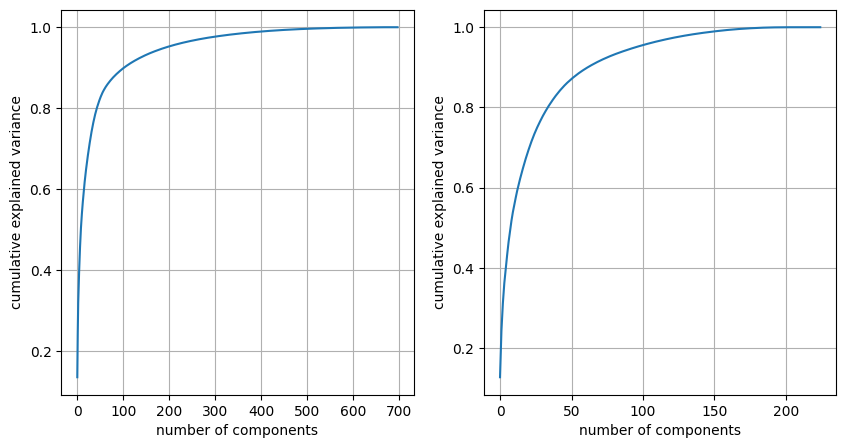

In [122]:
from sklearn.decomposition import PCA

pca_tr = PCA().fit(X_tr)
pca_vd = PCA().fit(X_vd)
fig, ax = plt.subplots(1, 2, figsize=(10, 5))
ax[0].plot(np.cumsum(pca_tr.explained_variance_ratio_))
ax[0].grid()
ax[0].set_xlabel('number of components')
ax[0].set_ylabel('cumulative explained variance');

plt.plot(np.cumsum(pca_vd.explained_variance_ratio_))
plt.grid()
plt.xlabel('number of components')
plt.ylabel('cumulative explained variance');

In [123]:
pca = PCA(0.995)
pca.fit(X_tr)
X_tr = pca.transform(X_tr) 
X_vd = pca.transform(X_vd)
X_ts = pca.transform(X_ts)

In [124]:
print(np.shape(X_tr))
print(np.shape(X_vd))
print(np.shape(X_ts))

(4275, 479)
(225, 479)
(500, 479)


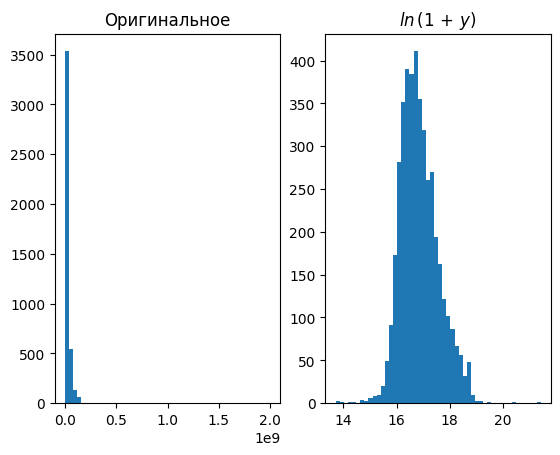

In [125]:
#посмотрим распределение целевой переменной
fig, ax = plt.subplots(1, 2)

ax[0].hist(Y_tr, bins=50);
ax[0].set_title('Оригинальное')
ax[1].set_title(r'$ln\, (1 \, + \, y)$')
ax[1].hist(np.log(1 + Y_tr), bins=50);


In [126]:
Y_tr_mape = Y_tr
Y_vd_mape = Y_vd
Y_tr_cb_mape = Y_tr_cb
Y_vd_cb_mape = Y_vd_cb

Y_tr = np.log(Y_tr + 1)
Y_vd = np.log(Y_vd + 1)
Y_tr_cb = np.log(Y_tr_cb + 1)
Y_vd_cb = np.log(Y_vd_cb + 1)

Бейслайн: предсказание медианой

In [127]:
from typing import Union
from sklearn.metrics import mean_absolute_percentage_error as mape

class DumbRegressor:
    def __init__(self):
        self.median = 0.

    def fit(self, X : Union[pd.DataFrame, np.array], Y : pd.DataFrame = None) -> "DumbRegressor" :
        if isinstance(X, np.ndarray):
            self.median = np.median(X)
            return self 
        
        if (X is not None):
            if 'price' in X.columns:
                if (X['price'].dtype == object):
                    self.median = X['price'].astype(float).median()
                else:
                    self.median = X['price'].median()
        elif (Y is not None):
            if 'price' in Y.columns:
                if (Y['price'].dtype == object):
                    self.median = Y['price'].astype(float).median()
                else:
                    self.median = Y['price'].median()
        else:
            raise RuntimeError("Can't learn on empty dataset!")
        
        return self 
        
    def predict(self, X :  pd.DataFrame = None) -> np.ndarray :
        if (X is not None):
            return np.ones(np.size(X, axis=0)) * self.median
        else:
            raise RuntimeError("Norhing to predict!")
    def loss(self, Y_model : Union[np.ndarray, pd.Series, pd.DataFrame, list], 
                    Y_test : Union[np.ndarray, pd.Series, pd.DataFrame, list]) -> float :
        
        if isinstance(Y_model, pd.DataFrame) and isinstance(Y_test, pd.DataFrame):
            if 'price' in Y_model.columns and 'price' in Y_test.columns :
                return mape(Y_model['price'], Y_test['price'])
        elif isinstance(Y_model, pd.DataFrame):
            if 'price' in Y_model.columns :
                return mape(Y_model['price'], Y_test)
        elif isinstance(Y_test, pd.DataFrame):
            if 'price' in Y_test.columns :
                return mape(Y_model, Y_test['price'])
        else:
            return mape(Y_model, Y_test)

In [128]:
dmbReg = DumbRegressor()
dmbReg.fit(Y_tr_mape)
Y_dummy = dmbReg.predict(X_vd)
dmbReg.loss(Y_dummy, Y_vd_mape)

0.9644682799840727

применяем xgboost

In [129]:
""" from plotly.io import show

dtrain = xgb.DMatrix(X_tr, label= Y_tr)
dtest = xgb.DMatrix(X_vd, label= Y_vd)

modelXG = XGBRegressor(
    n_estimators=500, 
    learning_rate=0.05, 
    max_depth=6, 
    subsample=0.5,
    reg_lambda=3
) """

' from plotly.io import show\n\ndtrain = xgb.DMatrix(X_tr, label= Y_tr)\ndtest = xgb.DMatrix(X_vd, label= Y_vd)\n\nmodelXG = XGBRegressor(\n    n_estimators=500, \n    learning_rate=0.05, \n    max_depth=6, \n    subsample=0.5,\n    reg_lambda=3\n) '

In [130]:
""" #уже гораздо лучше, но нужно искать оптимальные параметры с помощью optuna

modelXG.fit(X_tr, Y_tr)
Y_vd_xg = modelXG.predict(X_vd)

mape(Y_vd_xg, Y_vd) """

' #уже гораздо лучше, но нужно искать оптимальные параметры с помощью optuna\n\nmodelXG.fit(X_tr, Y_tr)\nY_vd_xg = modelXG.predict(X_vd)\n\nmape(Y_vd_xg, Y_vd) '

применяем catboost

In [131]:
cbreg = CatBoostRegressor(n_estimators=100,
                          max_depth=6,
                          loss_function='MAPE',
                          random_state=RAND_SEED,
                          learning_rate=0.1,
                          verbose=10,
                          eval_metric='MAPE', l2_leaf_reg=4.0, subsample=0.5)

In [132]:
cbreg.fit(X_tr_cb, Y_tr_cb, cat_features=cbCols, eval_set=(X_vd_cb, Y_vd_cb))

0:	learn: 0.0304627	test: 0.0327253	best: 0.0327253 (0)	total: 24.2ms	remaining: 2.39s
10:	learn: 0.0185338	test: 0.0200933	best: 0.0200933 (10)	total: 279ms	remaining: 2.25s
20:	learn: 0.0132692	test: 0.0140628	best: 0.0140628 (20)	total: 527ms	remaining: 1.98s
30:	learn: 0.0114889	test: 0.0122462	best: 0.0122462 (30)	total: 776ms	remaining: 1.73s
40:	learn: 0.0105408	test: 0.0114312	best: 0.0114312 (40)	total: 1.02s	remaining: 1.46s
50:	learn: 0.0100582	test: 0.0108340	best: 0.0108340 (50)	total: 1.24s	remaining: 1.19s
60:	learn: 0.0096607	test: 0.0104215	best: 0.0104215 (60)	total: 1.52s	remaining: 970ms
70:	learn: 0.0093679	test: 0.0102106	best: 0.0102106 (70)	total: 1.81s	remaining: 741ms
80:	learn: 0.0091016	test: 0.0099946	best: 0.0099946 (80)	total: 2.12s	remaining: 497ms
90:	learn: 0.0088291	test: 0.0098095	best: 0.0098095 (90)	total: 2.39s	remaining: 237ms
99:	learn: 0.0086274	test: 0.0097186	best: 0.0097186 (99)	total: 2.65s	remaining: 0us

bestTest = 0.009718564645
bestIter

In [133]:
Y_vd_model = cbreg.predict(X_vd_cb)
Y_vd_model = np.exp(Y_vd_model) - 1
mape(Y_vd_model, Y_vd_cb_mape)

0.1734181783180266

Полносвязная нейросеть

In [134]:
from torch.utils.data import Dataset, DataLoader

In [135]:
class SimpleNet(torch.nn.Module):
    def __init__(self, input_size : int, hid_size_1 : int, hid_size_2 : int, hid_size_3 : int, num_outputs : int, slope : float = 0.01) -> None:
        super().__init__()

        self.model = torch.nn.Sequential(
            torch.nn.Linear(input_size, hid_size_1),
            torch.nn.LeakyReLU(negative_slope=slope),
            torch.nn.Linear(hid_size_1, hid_size_2),
            torch.nn.LeakyReLU(negative_slope=slope),
            torch.nn.Linear(hid_size_2, hid_size_3),
            torch.nn.LeakyReLU(negative_slope=slope),
            torch.nn.Linear(hid_size_3, num_outputs)
        )

    def forward(self, X : torch.tensor) -> torch.tensor:
        return self.model(X)

In [136]:
class FLATDataset(Dataset):
    def __init__(self, data_X, data_y):
        self.X = torch.tensor(data_X.astype('float32'));
        self.y = torch.tensor(data_y.astype('float32'));

    def __len__(self):
        return self.X.shape[0];

    def __getitem__(self, index):
        return self.X[index], self.y[index]

In [137]:
train_dataset = FLATDataset(X_tr, Y_tr.to_numpy())
val_dataset = FLATDataset(X_vd, Y_vd.to_numpy())

In [138]:
batch_size = 512

train_dataloader = DataLoader(train_dataset, batch_size = batch_size, shuffle = True, pin_memory = True)
test_dataloader = DataLoader(val_dataset, batch_size = batch_size, shuffle = False)

In [139]:
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cpu'

In [140]:
my_simple_model = SimpleNet(input_size = np.size(X_tr, axis=1), hid_size_1 = 500, hid_size_2 = 100, hid_size_3 = 10, slope = 0.01, num_outputs = 1)
my_simple_model.to(device)
criterion = nn.L1Loss()
optimizer_for_simple_model = torch.optim.Adam(my_simple_model.parameters(), lr = 0.001)

In [141]:
def train(model, criterion, optimizer, train_dataloader, test_dataloader, num_epoch):
    train_losses = np.zeros(num_epoch)
    test_losses = np.zeros(num_epoch)
    
    train_mapes_arr = np.zeros(num_epoch)
    test_mapes_arr = np.zeros(num_epoch)
    
    for i_epoch in tqdm(range(num_epoch)):
        train_loss = 0
        test_loss = 0
        
        train_mape = 0
        test_mape = 0
        
        
        model.train()
        for batch in train_dataloader:
            X = batch[0].to(device)
            y = batch[1].to(device)
            
            preds = model(X)
            
            
            optimizer.zero_grad()
            loss = criterion(preds, y)
            loss.backward()
            optimizer.step()

            train_loss += loss.detach().cpu().numpy()
            train_mape += mape(y.cpu().numpy(), preds.cpu().detach().numpy())
            
        train_loss /= len(train_dataloader)
        #train_mape /= len(train_dataloader)
        train_losses[i_epoch] = train_loss
        train_mapes_arr[i_epoch] = train_mape
        
        model.eval()
        for batch in test_dataloader:
            X = batch[0].to(device)
            y = batch[1].to(device)
            
            with torch.no_grad():
                preds = model(X)
                loss = criterion(preds, y)
                
                test_loss += loss.cpu().numpy()
                test_mape += mape(y.cpu().numpy(), preds.cpu().detach().numpy())
                
        test_loss /= len(test_dataloader)
        #test_mape /= len(test_dataloader)
        
        test_losses[i_epoch] = test_loss
        test_mapes_arr[i_epoch] = test_mape
        
    return train_losses, test_losses, train_mapes_arr, test_mapes_arr

In [142]:
train_losses, test_losses, train_mapes_arr, test_mapes_arr = train(my_simple_model, criterion = criterion, optimizer= optimizer_for_simple_model, train_dataloader= train_dataloader, test_dataloader = 
      test_dataloader, num_epoch = 500)

100%|██████████| 500/500 [00:30<00:00, 16.20it/s]


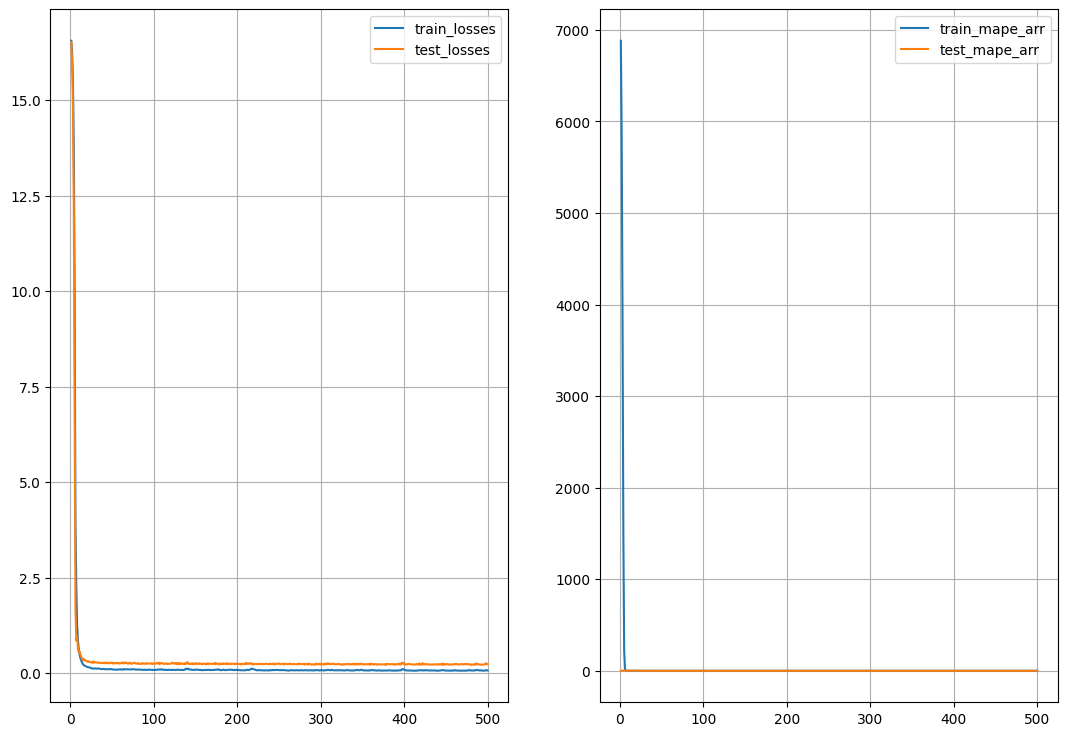

In [ ]:
fig, ax = plt.subplots(1,2, figsize = (13, 9))

ax[0].plot(np.arange(1, 1 + train_losses.shape[0]), train_losses, label = "train_losses")
ax[0].plot(np.arange(1, 1 + test_losses.shape[0]), test_losses, label = "test_losses")
ax[0].grid()
ax[1].grid()
ax[0].legend()
ax[1].legend();

In [144]:
#тоже неплохо, хотя требуется оптимизатор
X_vd_t = torch.tensor(X_vd.astype('float32'))
Y_vd_t = np.exp(my_simple_model(X_vd_t).detach()) - 1
mape(Y_vd_mape, Y_vd_t.detach())

0.2169056108898843

Оптимизация бустинга

In [145]:
""" n_trials = 100

def gridSearchXG(trial):

    params = {
        "n_estimators": trial.suggest_int("n_estimators", 100, 5000, step=50),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
        "max_depth": trial.suggest_int("max_depth", 2, 8),
        "tree_method" : 'hist',
        'min_child_weight' : trial.suggest_int('min_child_weight', 1, 96, step = 5),
        "subsample": trial.suggest_float("subsample", 0.2, 1.0, step = 0.1),
        "reg_lambda": trial.suggest_float("reg_lambda", 0.0, 10.0, step = 0.5),
        "reg_alpha": trial.suggest_float("reg_alpha", 0.0, 10.0, step = 0.5),
        'early_stopping_rounds' : trial.suggest_int('early_stopping_rounds', 5, 50, step = 5),
        "random_state": RAND_SEED
    }

    
    model = xgb.XGBRegressor(**params)
    model.fit(X_tr, Y_tr, eval_set=[(X_vd, Y_vd)], verbose=False)
    y_pred = model.predict(X_vd)
    error = mape(Y_vd, y_pred)
    return error   

studyXG = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(), 
                            pruner=optuna.pruners.HyperbandPruner(), study_name='XGBoostRegressor')  
studyXG.optimize(gridSearchXG, n_trials=n_trials) """

' n_trials = 100\n\ndef gridSearchXG(trial):\n\n    params = {\n        "n_estimators": trial.suggest_int("n_estimators", 100, 5000, step=50),\n        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3, log=True),\n        "max_depth": trial.suggest_int("max_depth", 2, 8),\n        "tree_method" : \'hist\',\n        \'min_child_weight\' : trial.suggest_int(\'min_child_weight\', 1, 96, step = 5),\n        "subsample": trial.suggest_float("subsample", 0.2, 1.0, step = 0.1),\n        "reg_lambda": trial.suggest_float("reg_lambda", 0.0, 10.0, step = 0.5),\n        "reg_alpha": trial.suggest_float("reg_alpha", 0.0, 10.0, step = 0.5),\n        \'early_stopping_rounds\' : trial.suggest_int(\'early_stopping_rounds\', 5, 50, step = 5),\n        "random_state": RAND_SEED\n    }\n\n    \n    model = xgb.XGBRegressor(**params)\n    model.fit(X_tr, Y_tr, eval_set=[(X_vd, Y_vd)], verbose=False)\n    y_pred = model.predict(X_vd)\n    error = mape(Y_vd, y_pred)\n    return error   \n\nst

In [146]:
""" fig_imp = optuna.visualization.plot_param_importances(studyXG)
show(fig_imp) """

' fig_imp = optuna.visualization.plot_param_importances(studyXG)\nshow(fig_imp) '

In [147]:
""" fig_timeline = optuna.visualization.plot_timeline(studyXG)
show(fig_timeline) """

' fig_timeline = optuna.visualization.plot_timeline(studyXG)\nshow(fig_timeline) '

In [148]:
""" paramsXG = studyXG.best_params
print("Лучшие параметры:", paramsXG) """

' paramsXG = studyXG.best_params\nprint("Лучшие параметры:", paramsXG) '

In [149]:
""" XG_best = XGBRegressor(**paramsXG)
XG_best.fit(X_tr, Y_tr, eval_set=[(X_vd, Y_vd)])

Y_xg = XG_best.predict(X_vd)

mape(Y_xg, Y_vd) """

' XG_best = XGBRegressor(**paramsXG)\nXG_best.fit(X_tr, Y_tr, eval_set=[(X_vd, Y_vd)])\n\nY_xg = XG_best.predict(X_vd)\n\nmape(Y_xg, Y_vd) '

In [150]:
n_trials = 5

def gridSearchCB(trial):

    params = {
        "n_estimators": trial.suggest_int("n_estimators", 100, 5000, step = 50),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
        "max_depth": trial.suggest_int("max_depth", 3, 8),
        "subsample": trial.suggest_float("subsample", 0.2, 1.0, step = 0.1), 
        "l2_leaf_reg": trial.suggest_float("l2_leaf_reg", 0., 10.0, step = 0.2), 
        'early_stopping_rounds': trial.suggest_int('early_stopping_rounds', 0, 100, step = 5),
        "random_state": RAND_SEED
    }

    
    model = CatBoostRegressor(**params)
    model.fit(X_tr_cb, Y_tr_cb, cat_features=cbCols, eval_set=(X_vd_cb, Y_vd_cb), verbose=False)
    y_pred = model.predict(X_vd_cb)
    error = mape(Y_vd_cb, y_pred)
    return error  

studyCB = optuna.create_study(direction="minimize", sampler=optuna.samplers.RandomSampler(), 
                            pruner=optuna.pruners.MedianPruner(), study_name='CatBoostRegressor')  
studyCB.optimize(gridSearchCB, n_trials=n_trials)

[I 2025-03-21 12:21:54,178] A new study created in memory with name: CatBoostRegressor
[I 2025-03-21 12:25:30,887] Trial 0 finished with value: 0.007966923404171268 and parameters: {'n_estimators': 4400, 'learning_rate': 0.013672272010583256, 'max_depth': 8, 'subsample': 0.9000000000000001, 'l2_leaf_reg': 7.4, 'early_stopping_rounds': 70}. Best is trial 0 with value: 0.007966923404171268.
[I 2025-03-21 12:26:08,181] Trial 1 finished with value: 0.007937292187296146 and parameters: {'n_estimators': 4750, 'learning_rate': 0.08983884841348444, 'max_depth': 6, 'subsample': 0.5, 'l2_leaf_reg': 7.4, 'early_stopping_rounds': 50}. Best is trial 1 with value: 0.007937292187296146.
[I 2025-03-21 12:26:36,560] Trial 2 finished with value: 0.008317413399713126 and parameters: {'n_estimators': 4750, 'learning_rate': 0.10796372702800998, 'max_depth': 3, 'subsample': 0.6000000000000001, 'l2_leaf_reg': 5.6000000000000005, 'early_stopping_rounds': 95}. Best is trial 1 with value: 0.007937292187296146.


In [158]:
fig_timeline = optuna.visualization.plot_param_importances(studyCB)
show(fig_timeline)

In [154]:
fig_timeline = optuna.visualization.plot_timeline(studyCB)
show(fig_timeline)

In [156]:
best_paramsCB = studyCB.best_params
print("Лучшие параметры:", best_paramsCB)

Лучшие параметры: {'n_estimators': 4750, 'learning_rate': 0.08983884841348444, 'max_depth': 6, 'subsample': 0.5, 'l2_leaf_reg': 7.4, 'early_stopping_rounds': 50}


In [1]:
""" CB_best = CatBoostRegressor(**best_paramsCB)
CB_best.fit(X_tr_cb, Y_tr_cb, cat_features=cbCols, verbose = False) """

' CB_best = CatBoostRegressor(**best_paramsCB)\nCB_best.fit(X_tr_cb, Y_tr_cb, cat_features=cbCols, verbose = False) '

In [ ]:
""" Y_pred_cb = CB_best.predict(X_vd_cb)
#Y_pred_cb = np.exp(Y_pred_cb) - 1 
 
mape(Y_pred_cb, Y_vd) """

0.04527895813559787

Оптимизация нейросети

In [166]:
def trainNN(model, train_dataloader, test_dataloader, num_epoch, lr, 
            input_size, hid_size_1, hid_size_2, hid_size_3, num_outputs, slope) -> float:
    
    net = model(input_size, hid_size_1, hid_size_2, hid_size_3, num_outputs, slope)
    net.to(device)
    
    criterion = nn.L1Loss()
    optimizer_for_net = torch.optim.Adam(net.parameters(), lr = lr)

    for i_epoch in (range(num_epoch)):

        train_loss = 0
        test_loss = 0
        train_mape = 0
        test_mape = 0
        
        net.train()
        for batch in train_dataloader:
            X = batch[0].to(device)
            y = batch[1].to(device)

            preds = net(X)
            
            optimizer_for_net.zero_grad()
            loss = criterion(preds, y)
            loss.backward()
            optimizer_for_net.step()
            
            train_loss += loss.item()
            train_mape += mape(y.cpu().numpy(), preds.cpu().detach().numpy())

        train_loss /= len(train_dataloader)
        train_mape /= len(train_dataloader)

        # Оценка на тестовых данных
        net.eval()
        with torch.no_grad():
            for batch in test_dataloader:
                X = batch[0].to(device)
                y = batch[1].to(device)
                
                preds = net(X)
                loss = criterion(preds, y)
                
                test_loss += loss.item()
                test_mape += mape(y.cpu().numpy(), preds.cpu().detach().numpy())
        
        test_loss /= len(test_dataloader)
        test_mape /= len(test_dataloader)

    return test_mape

In [167]:
n_trials = 5

def gridSearchNN(trial, model, train_dataloader, test_dataloader):

    params = {
        'input_size' : np.size(X_tr, axis=1),
        "hid_size_1": trial.suggest_int("hid_size_1", 250, 1000, step=50),
        "hid_size_2": trial.suggest_int("hid_size_2", 50, 500, step=50),
        "hid_size_3": trial.suggest_int("hid_size_3", 10, 250, step=10),
        'slope' : trial.suggest_float("slope", 0.001, 0.5, log=True),
        'num_outputs' : 1,
        'lr' : trial.suggest_float('lr', 1e-5, 1e-1, log=True),
        'num_epoch' :  trial.suggest_int('epo', 50, 500, step = 10)
    }

    return trainNN(model, train_dataloader, test_dataloader, **params)

studyNN = optuna.create_study(direction="minimize", sampler=optuna.samplers.RandomSampler(), 
                            pruner=optuna.pruners.MedianPruner(), study_name='Fully-Connected NN')  
studyNN.optimize(lambda trial: gridSearchNN(trial, SimpleNet, train_dataloader, test_dataloader), n_trials=n_trials)

[I 2025-03-21 12:32:20,159] A new study created in memory with name: Fully-Connected NN
[I 2025-03-21 12:32:35,698] Trial 0 finished with value: 0.014335024170577526 and parameters: {'hid_size_1': 350, 'hid_size_2': 200, 'hid_size_3': 90, 'slope': 0.4337571092905082, 'lr': 0.053622061731279556, 'epo': 230}. Best is trial 0 with value: 0.014335024170577526.
[I 2025-03-21 12:33:15,313] Trial 1 finished with value: 0.01633673533797264 and parameters: {'hid_size_1': 850, 'hid_size_2': 250, 'hid_size_3': 230, 'slope': 0.0038560713283951045, 'lr': 0.0018983144123217283, 'epo': 440}. Best is trial 0 with value: 0.014335024170577526.
[I 2025-03-21 12:33:55,159] Trial 2 finished with value: 0.014356303960084915 and parameters: {'hid_size_1': 900, 'hid_size_2': 150, 'hid_size_3': 100, 'slope': 0.004134715457646751, 'lr': 5.9624867594064235e-05, 'epo': 500}. Best is trial 0 with value: 0.014335024170577526.
[I 2025-03-21 12:34:10,960] Trial 3 finished with value: 0.011940831318497658 and paramete

In [168]:
fig_imp = optuna.visualization.plot_param_importances(studyNN)
show(fig_imp)

In [169]:
fig_timeline = optuna.visualization.plot_timeline(studyNN)
show(fig_timeline)

In [170]:
paramsNN = studyNN.best_params
print("Лучшие параметры:", paramsNN)

Лучшие параметры: {'hid_size_1': 600, 'hid_size_2': 50, 'hid_size_3': 160, 'slope': 0.3557243619953436, 'lr': 0.00023997856209137907, 'epo': 240}


In [172]:
NN_best = SimpleNet(input_size=np.size(X_tr, axis=1),  hid_size_1 = paramsNN['hid_size_1'], 
                hid_size_2 = paramsNN['hid_size_2'], hid_size_3 = paramsNN['hid_size_3'], 
                num_outputs = 1, slope = paramsNN['slope'])
NN_best.to(device)

criterion = nn.L1Loss()
optimizer_for_net = torch.optim.Adam(NN_best.parameters(), lr = paramsNN['lr'])

for i_epoch in (range(paramsNN['epo'])):

    train_loss = 0
    test_loss = 0
    train_mape = 0
    test_mape = 0
    
    NN_best.train()
    for batch in train_dataloader:
        X = batch[0].to(device)
        y = batch[1].to(device)

        preds = NN_best(X)
        
        optimizer_for_net.zero_grad()
        loss = criterion(preds, y)
        loss.backward()
        optimizer_for_net.step()
        
        train_loss += loss.item()
        train_mape += mape(y.cpu().numpy(), preds.cpu().detach().numpy())

    train_loss /= len(train_dataloader)
    #train_mape /= len(train_dataloader)

    # Оценка на тестовых данных
    NN_best.eval()
    with torch.no_grad():
        for batch in test_dataloader:
            X = batch[0].to(device)
            y = batch[1].to(device)
            
            preds = NN_best(X)
            loss = criterion(preds, y)
                
            test_loss += loss.item()
            test_mape += mape(y.cpu().numpy(), preds.cpu().detach().numpy())
        
        test_loss /= len(test_dataloader)
        #test_mape /= len(test_dataloader)
test_mape
                

0.011622719466686249

Метаалгоритм для стекинга

In [173]:
X_vd_t = torch.tensor(X_vd.astype('float32'))
X_ts_t = torch.tensor(X_ts.astype('float32'))

In [174]:
from sklearn.svm import SVR

X_svr_tr = np.zeros((np.size(X_vd, 0), 2))
X_svr_ts = np.zeros((np.size(X_ts, 0), 2))

Y_svr_tr = np.log(1 + Y_vd['price'])

X_svr_tr[:, 0] = CB_best.predict(X_vd_cb)

X_svr_ts[:, 0] = CB_best.predict(X_ts_cb)

NN_best.eval()
with torch.no_grad():
    X_svr_tr[:, 1] = NN_best(X_vd_t).squeeze(-1)
    X_svr_ts[:, 1] = NN_best(X_ts_t).squeeze(-1)

scaler_meta = StandardScaler()
X_svr_tr_scaled = scaler_meta.fit_transform(X_svr_tr)
X_svr_ts_scaled = scaler_meta.transform(X_svr_ts)


In [175]:
metamod = SVR(kernel='rbf', C=1.0, epsilon=0.1, gamma='scale')

metamod.fit(X_svr_tr_scaled, Y_svr_tr)
Y_ts = np.exp(metamod.predict(X_svr_ts_scaled)) - 1

In [176]:
names = ['id', 'val']
vals = [[x, y] for x,y in zip(test_id, Y_pred_cb)]
submition = pd.DataFrame(data=vals, columns=names).set_index("id")
submition.to_csv("submition.csv", sep =',')